# Feature Engineering
---
| | |
|---|---|
| **Thesis Title** | A Machine Learning Approach to Solar Irradiance Prediction Using Historical Weather Data |
| **Programme** | B.Sc. Internet Informatics |
| **Institution** | Kaunas University of Technology |
| **Notebook** | 02 — Feature Engineering for Solar Irradiance |
| **Target Variable** | Global Horizontal Irradiance — GHI (W/m²) |

---
### Notebook Objectives
This notebook performs systematic feature engineering on the preprocessed hourly solar irradiance dataset for the year 2022.
1. Decompose the datetime index into all the feature-engineered calendar features
2. Created Cyclic encoding for all the possible values for our models
3. Derive solar physics features (clear-sky index, zenith transforms, diffuse fraction)
4. Engineered lag features on different time periods
5. Created rolling statistics for the ML models
6. We have encoded a seasonal categorical column
7. We exported the engineered file into a new CSV file for our train/test split

## Table of Contents
1. [Setup and Data Loading](#setup)
2. [Calendar Features](#cal)
3. [Cyclic Encoding](#cycle)
4. [Solar Physics Features](#solar)
5. [Lag Features](#lag)
6. [Rolling Windows Statistics](#roll)
7. [Interaction & Ratio Features](#inter)
8. [Categorical Encoding](#category)
9. [Correlation & Feature Relevance Analysis](#coor)
10. [Export Feature Engineered Data](#export)
11. [Feature Engineering Summary](#feat)

---
<a id="setup"></a>
## 1. Setup and Data Loading

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
SEED = 42
np.random.seed(SEED)

In [55]:
df= pd.read_csv('../data/df_processed.csv', index_col='Date Time', parse_dates=True)

In [56]:
df.head()

,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Relative Humidity,Wind Direction,Wind Speed,DHI,DNI,GHI,Solar Zenith Angle,Precipitable Water,Surface Albedo,Season
Date Time,,,,,,,,,,,,,,,
2022-01-01 00:30:00,4.9,0,0,0,1,69.27,172,3.4,0,0,0,159.08,1.4,0.17,Winter
2022-01-01 01:30:00,5.2,0,0,0,4,57.26,183,1.6,0,0,0,161.96,0.5,0.16,Winter
2022-01-01 02:30:00,5.3,0,0,0,0,55.49,184,1.5,0,0,0,157.00,0.5,0.16,Winter
2022-01-01 03:30:00,5.3,0,0,0,0,54.39,184,1.5,0,0,0,147.66,0.5,0.16,Winter
2022-01-01 04:30:00,5.3,0,0,0,4,53.39,184,1.4,0,0,0,136.82,0.5,0.16,Winter


In [57]:
df.shape

(8760, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2022-01-01 00:30:00 to 2022-12-31 23:30:00
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Temperature         8760 non-null   float64
 1   Clearsky DHI        8760 non-null   int64  
 2   Clearsky DNI        8760 non-null   int64  
 3   Clearsky GHI        8760 non-null   int64  
 4   Cloud Type          8760 non-null   int64  
 5   Relative Humidity   8760 non-null   float64
 6   Wind Direction      8760 non-null   int64  
 7   Wind Speed          8760 non-null   float64
 8   DHI                 8760 non-null   int64  
 9   DNI                 8760 non-null   int64  
 10  GHI                 8760 non-null   int64  
 11  Solar Zenith Angle  8760 non-null   float64
 12  Precipitable Water  8760 non-null   float64
 13  Surface Albedo      8760 non-null   float64
 14  Season              8760 non-null   object 
dtypes: float64(6), int6

---
<a id=cal></a>
## 2. Calendar Features

In this section, we will decompose all the timestamps into components that allow the model to learn the periodic patterns like weekly, diurnal and seasonal cycles

In [7]:
df['hour']         = df.index.hour                        # 0–23
df['day_of_week']  = df.index.dayofweek                   # 0=Mon … 6=Sun
df['day_of_year']  = df.index.dayofyear                   # 1–365
df['week_of_year'] = df.index.isocalendar().week.astype(int)  # 1–53
df['month']        = df.index.month                       # 1–12
df['quarter']      = df.index.quarter                     # 1–4
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_daytime']   = (df['Clearsky GHI'] > 0).astype(int) #solar elevation is positive when GHI>0

In [9]:
print('Added Calendar Features:')
cal_cols = ['hour', 'day_of_week', 'day_of_year', 'week_of_year',
            'month', 'quarter', 'is_weekend', 'is_daytime']
print(df[cal_cols].head(6).to_string())

Added Calendar Features:
                     hour  day_of_week  day_of_year  week_of_year  month  quarter  is_weekend  is_daytime
Date Time                                                                                                
2022-01-01 00:30:00     0            5            1            52      1        1           1           0
2022-01-01 01:30:00     1            5            1            52      1        1           1           0
2022-01-01 02:30:00     2            5            1            52      1        1           1           0
2022-01-01 03:30:00     3            5            1            52      1        1           1           0
2022-01-01 04:30:00     4            5            1            52      1        1           1           0
2022-01-01 05:30:00     5            5            1            52      1        1           1           0


---
<a id=cycle></a>
## 3. Cyclic Encoding

Raw temporal indices are non-numeric and periodic; sine/cosine projection maps them onto a unit circle, preserving cyclic continuity.

In [12]:

cyclic_map = {
    'hour'        : 24,
    'day_of_week' : 7,
    'day_of_year' : 365,
    'month'       : 12,
    'week_of_year': 52,
}

for col, period in cyclic_map.items():
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)

print('Cyclic Encoding features created:')
cyc_cols = []
for c in cyclic_map:
    for s in ('sin', 'cos'):
        cyc_cols.append(f'{c}_{s}')
print(cyc_cols)


Cyclic Encoding features created:
['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos']


### Visualising cyclic encoding for an hour

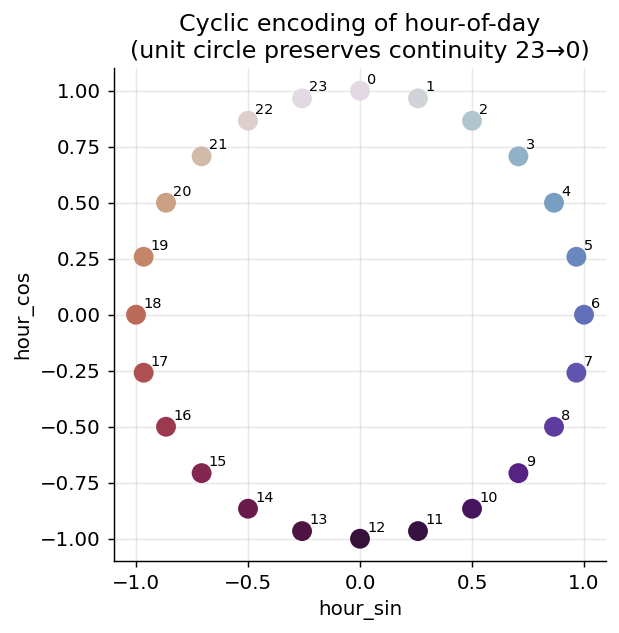

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
hours = np.arange(24)
ax.scatter(
    np.sin(2 * np.pi * hours / 24),
    np.cos(2 * np.pi * hours / 24),
    c=hours, cmap='twilight', s=100, zorder=5
)
for h in hours:
    ax.annotate(
        str(h),
        (np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)),
        textcoords='offset points', xytext=(4, 4), fontsize=8
    )
ax.set_xlabel('hour_sin')
ax.set_ylabel('hour_cos')
ax.set_title('Cyclic encoding of hour-of-day\n(unit circle preserves continuity 23→0)')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../outputs/figures/plot_cyclic_hour_encoding.png', bbox_inches='tight')
plt.show()

---
<a id=solar></a>
## 4. Solar Physics Features

### 4.1 Clear-Sky Index (kt)

It captures the cloud thickness. values near 1 indicate clear sky, near 0 values indicate heavy overcast.

$$K_t = \frac{\text{GHI}}{\text{Clearsky GHI}}$$

In [18]:
# Avoid division by zero during night hours
df['kt_ghi'] = np.where(
    df['Clearsky GHI'] > 0,
    df['GHI'] / df['Clearsky GHI'],
    0.0
)
# Clip to [0, 1.2] — values slightly above 1 occur due to cloud-edge enhancement
df['kt_ghi'] = df['kt_ghi'].clip(0, 1.2)

# DHI and DNI clearness indices
df['kt_dhi'] = np.where(df['Clearsky DHI'] > 0,
                         df['DHI'] / df['Clearsky DHI'], 0.0).clip(0, 1.2)
df['kt_dni'] = np.where(df['Clearsky DNI'] > 0,
                         df['DNI'] / df['Clearsky DNI'], 0.0).clip(0, 1.2)

print('Clear-sky indices:')
print(df[['GHI','Clearsky GHI','kt_ghi','kt_dhi','kt_dni']]
      .describe().round(3))

Clear-sky indices:
            GHI  Clearsky GHI    kt_ghi    kt_dhi    kt_dni
count  8760.000      8760.000  8760.000  8760.000  8760.000
mean    183.588       240.614     0.355     0.488     0.269
std     277.096       315.734     0.428     0.527     0.422
min       0.000         0.000     0.000     0.000     0.000
25%       0.000         0.000     0.000     0.000     0.000
50%       0.000         0.000     0.000     0.000     0.000
75%     323.000       469.000     0.849     1.000     0.530
max    1031.000      1031.000     1.000     1.200     1.000


### 4.2 Solar Zenith Angle Transformation
cosine and sine of zenith are proportional to the direct normal component projected. It is more meaningful than just a raw angle.

In [20]:
zenith_rad = np.deg2rad(df['Solar Zenith Angle'])
df['cos_zenith'] = np.cos(zenith_rad)
df['sin_zenith'] = np.sin(zenith_rad)   # captures scattering path length

# ── 4.3 Diffuse fraction (df / ghi) ─────────────────────────────────────────
df['diffuse_fraction'] = np.where(
    df['GHI'] > 0,
    df['DHI'] / df['GHI'],
    0.0
).clip(0, 1)

print('Solar physics features created: cos_zenith, sin_zenith, diffuse_fraction')
print(df[['Solar Zenith Angle','cos_zenith','sin_zenith','diffuse_fraction']]
      .describe().round(3))

Solar physics features created: cos_zenith, sin_zenith, diffuse_fraction
       Solar Zenith Angle  cos_zenith  sin_zenith  diffuse_fraction
count            8760.000    8760.000    8760.000          8760.000
mean               89.663       0.005       0.819             0.278
std                35.650       0.545       0.181             0.382
min                17.650      -0.952       0.303             0.000
25%                62.140      -0.460       0.717             0.000
50%                89.205       0.014       0.886             0.000
75%               117.365       0.467       0.965             0.572
max               162.260       0.953       1.000             1.000


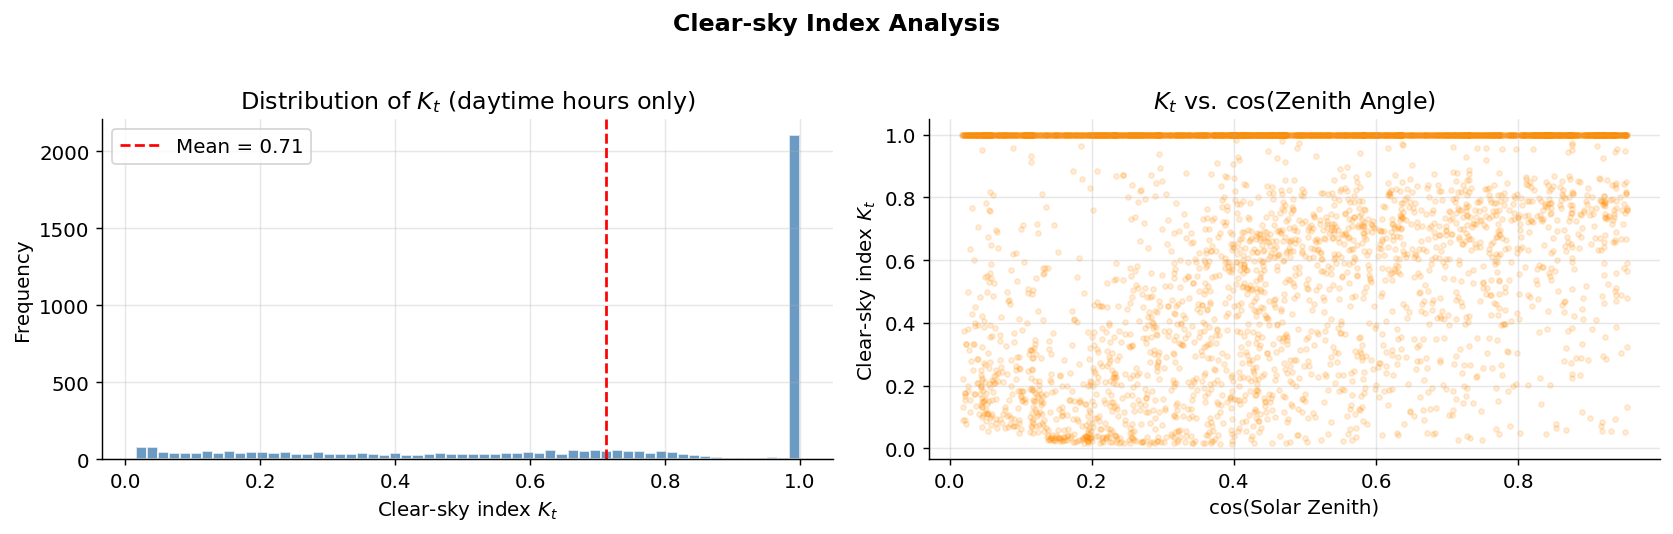

In [35]:
# Visualise Kt distribution
daytime = df[df['is_daytime'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(daytime['kt_ghi'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Clear-sky index $K_t$')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of $K_t$ (daytime hours only)')
axes[0].axvline(daytime['kt_ghi'].mean(), color='red', linestyle='--',
                label=f'Mean = {daytime["kt_ghi"].mean():.2f}')
axes[0].legend()

axes[1].scatter(daytime['cos_zenith'], daytime['kt_ghi'],
               alpha=0.15, s=8, color='darkorange')
axes[1].set_xlabel('cos(Solar Zenith)')
axes[1].set_ylabel('Clear-sky index $K_t$')
axes[1].set_title('$K_t$ vs. cos(Zenith Angle)')

plt.suptitle('Clear-sky Index Analysis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/plot_clearsky_index.png', bbox_inches='tight')
plt.show()

The distribution shows a dominant spike at Kₜ ≈ 1.0, reflecting the high proportion of clear-sky hours typical of the Spain region, for which we have acquired NSRDB data. The scatter plot confirms that cloud attenuation is the primary source of GHI variability, independent of solar geometry — making Kₜ a valuable feature for both models.

---
<a id=lag></a>
## 5. Lag Features

This feature gives XGBoost explicit access to the recent history of the target variable.They also inform SARIMAX order selection by revealing which past values carry the most predictive signal

| Lag | Physical meaning |
|---|---|
| 1 h | Previous hour (strong short-term autocorrelation) |
| 2 h | Two hours ago |
| 3 h | Three hours ago |
| 6 h | Half-day back |
| 24 h | Same hour yesterday (strong diurnal cycle) |

In [28]:
lag_hours = [1, 2, 3, 6, 24]

for lag in lag_hours:
    df[f'GHI_lag_{lag}h'] = df['GHI'].shift(lag)

# Lag features for clearness index (useful: captures recent cloud state)
for lag in [1, 2, 24]:
    df[f'kt_ghi_lag_{lag}h'] = df['kt_ghi'].shift(lag)

# Lag for Temperature (thermal inertia)
df['temp_lag_1h']  = df['Temperature'].shift(1)
df['temp_lag_24h'] = df['Temperature'].shift(24)

lag_cols = [f'GHI_lag_{l}h' for l in lag_hours]
print('Lag features created. Sample (daytime rows):')
print(df.loc[df['is_daytime']==1, ['GHI'] + lag_cols].head(5).to_string())

Lag features created. Sample (daytime rows):
                     GHI  GHI_lag_1h  GHI_lag_2h  GHI_lag_3h  GHI_lag_6h  GHI_lag_24h
Date Time                                                                            
2022-01-01 09:30:00   18         0.0         0.0         0.0         0.0          NaN
2022-01-01 10:30:00  141        18.0         0.0         0.0         0.0          NaN
2022-01-01 11:30:00  219       141.0        18.0         0.0         0.0          NaN
2022-01-01 12:30:00  296       219.0       141.0        18.0         0.0          NaN
2022-01-01 13:30:00  464       296.0       219.0       141.0         0.0          NaN


---
<a id=roll></a>
## 6. Rolling Windows Statistics

These features capture local temporal dynamics like short-term trends and variability

In [29]:
windows = [3, 6, 12, 24]

for w in windows:
    rolled = df['GHI'].shift(1).rolling(window=w, min_periods=1)
    df[f'GHI_roll_mean_{w}h'] = rolled.mean()
    df[f'GHI_roll_std_{w}h']  = rolled.std().fillna(0)
    df[f'GHI_roll_max_{w}h']  = rolled.max()
    df[f'GHI_roll_min_{w}h']  = rolled.min()

# Rolling mean of clearness index (cloud persistence signal)
for w in [3, 6, 24]:
    df[f'kt_roll_mean_{w}h'] = (
        df['kt_ghi'].shift(1).rolling(window=w, min_periods=1).mean()
    )


roll6 = df['GHI'].shift(1).rolling(window=6, min_periods=2)
df['GHI_variability_6h'] = (roll6.std() / roll6.mean().replace(0, np.nan)).fillna(0)

print('Rolling features created.')
roll_sample = [f'GHI_roll_mean_{w}h' for w in windows]
print(df[['GHI'] + roll_sample].describe().round(2))

Rolling features created.
           GHI  GHI_roll_mean_3h  GHI_roll_mean_6h  GHI_roll_mean_12h  \
count  8760.00           8759.00           8759.00            8759.00   
mean    183.59            183.61            183.61             183.56   
std     277.10            266.03            242.16             182.25   
min       0.00              0.00              0.00               0.00   
25%       0.00              0.00              0.00              29.62   
50%       0.00             19.00             61.50             126.58   
75%     323.00            310.83            300.58             285.46   
max    1031.00           1012.33            947.50             732.00   

       GHI_roll_mean_24h  
count            8759.00  
mean              183.47  
std               107.24  
min                 0.00  
25%                95.38  
50%               161.58  
75%               282.25  
max               378.92  


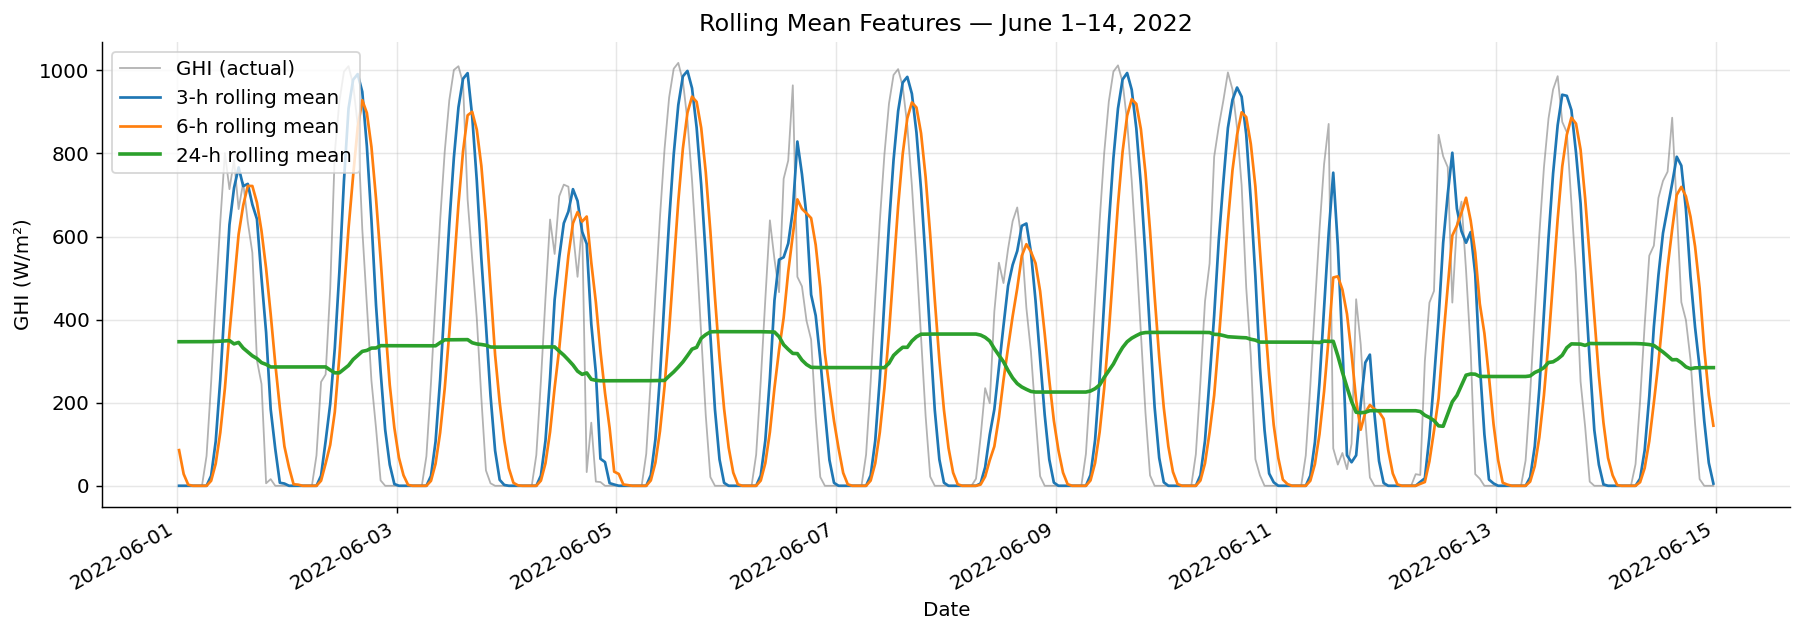

In [36]:
# ── Visualise rolling means on a sample week ─────────────────────────────────
sample = df['2022-06-01':'2022-06-14']  # two weeks in June

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample.index, sample['GHI'], lw=1, color='gray', alpha=0.6, label='GHI (actual)')
ax.plot(sample.index, sample['GHI_roll_mean_3h'],  lw=1.5, label='3-h rolling mean')
ax.plot(sample.index, sample['GHI_roll_mean_6h'],  lw=1.5, label='6-h rolling mean')
ax.plot(sample.index, sample['GHI_roll_mean_24h'], lw=2,   label='24-h rolling mean')
ax.set_xlabel('Date')
ax.set_ylabel('GHI (W/m²)')
ax.set_title('Rolling Mean Features — June 1–14, 2022')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('../outputs/figures/plot_rolling_means.png', bbox_inches='tight')
plt.show()

**Observation:** <br>
    The 3-hour and 6-hour rolling means are very close, with the actual GHI signals capturing short-term cloud transitions while smoothing out sudden spikes. The 24-hour rolling means act as a slow-moving baseline representing daily energy.

---
<a id=inter></a>
## 7. Interaction & Ratio Features

Domain-driven interaction terms capture combined physical effects that no single feature can represent alone.

In [39]:
# Temperature × Humidity: high temp + high humidity → haze effect
df['temp_x_humidity'] = df['Temperature'] * df['Relative Humidity'] / 100

# Cloud type × Clearsky GHI: cloud attenuation modulated by available irradiance
df['cloud_clearsky'] = df['Cloud Type'] * df['Clearsky GHI']

# Wind speed × Precipitable water: advection of moisture
df['wind_x_precip_water'] = df['Wind Speed'] * df['Precipitable Water']

# cos(zenith) × Clearsky GHI: effective solar input accounting for geometry
df['cos_zenith_x_clearsky'] = df['cos_zenith'] * df['Clearsky GHI']

# GHI change (first difference) — rate of change signal
df['GHI_diff_1h'] = df['GHI'].diff(1)
df['GHI_diff_24h'] = df['GHI'].diff(24)   # same-hour vs yesterday

print('Interaction features created:')
interaction_cols = ['temp_x_humidity','cloud_clearsky','wind_x_precip_water',
                    'cos_zenith_x_clearsky','GHI_diff_1h','GHI_diff_24h']
print(df[interaction_cols].describe().round(3))

Interaction features created:
       temp_x_humidity  cloud_clearsky  wind_x_precip_water  \
count         8760.000        8760.000             8760.000   
mean             6.735         707.905                3.683   
std              3.350        1538.989                2.976   
min             -4.511           0.000                0.080   
25%              4.661           0.000                1.520   
50%              7.081           0.000                2.860   
75%              9.117         364.250                4.960   
max             15.888        8865.000               24.840   

       cos_zenith_x_clearsky  GHI_diff_1h  GHI_diff_24h  
count               8760.000     8759.000      8736.000  
mean                 153.675        0.000         0.073  
std                  250.176      106.685       128.163  
min                   -0.000     -781.000      -944.000  
25%                   -0.000       -8.000         0.000  
50%                   -0.000        0.000         0.00

---
<a id=category></a>
## 8. Categorical Encoding

### 8.1 Season  
One-hot encoding avoids imposing an ordinal relationship between seasons.

In [41]:
# ── One-hot encode Season ────────────────────────────────────────────────────
season_dummies = pd.get_dummies(df['Season'], prefix='season', drop_first=False)
df = pd.concat([df, season_dummies], axis=1)

# Ordinal encoding (useful for tree models as an alternative)
season_ordinal = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
df['season_ordinal'] = df['Season'].map(season_ordinal)

print('Season encoding:')
print(df[['Season', 'season_ordinal'] + list(season_dummies.columns)]
      .drop_duplicates().sort_values('season_ordinal').to_string())

Season encoding:
                     Season  season_ordinal  season_Autumn  season_Spring  season_Summer  season_Winter
Date Time                                                                                              
2022-01-01 00:30:00  Winter               0          False          False          False           True
2022-03-01 00:30:00  Spring               1          False           True          False          False
2022-06-01 00:30:00  Summer               2          False          False           True          False
2022-09-01 00:30:00  Autumn               3           True          False          False          False


---
<a id=coor></a>
## 9. Correlation & Feature Relevance Analysis

In [42]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ('GHI', 'Date Time')]

corr_with_ghi = (
    df[numeric_cols + ['GHI']]
    .corr()['GHI']
    .drop('GHI')
    .abs()
    .sort_values(ascending=False)
)

print('Top 20 features by |Pearson r| with GHI:')
print(corr_with_ghi.head(20).round(4).to_string())

Top 20 features by |Pearson r| with GHI:
GHI_lag_1h               0.9259
Clearsky GHI             0.9206
cos_zenith_x_clearsky    0.9091
GHI_lag_24h              0.8932
DNI                      0.8446
GHI_roll_max_3h          0.8146
GHI_roll_mean_3h         0.8140
kt_ghi                   0.8090
Clearsky DNI             0.8053
Solar Zenith Angle       0.8013
cos_zenith               0.7970
GHI_lag_2h               0.7956
GHI_roll_min_3h          0.7720
kt_ghi_lag_1h            0.7584
Clearsky DHI             0.7385
kt_roll_mean_3h          0.7370
kt_dni                   0.7352
kt_dhi                   0.7211
hour_cos                 0.7130
kt_ghi_lag_24h           0.6938


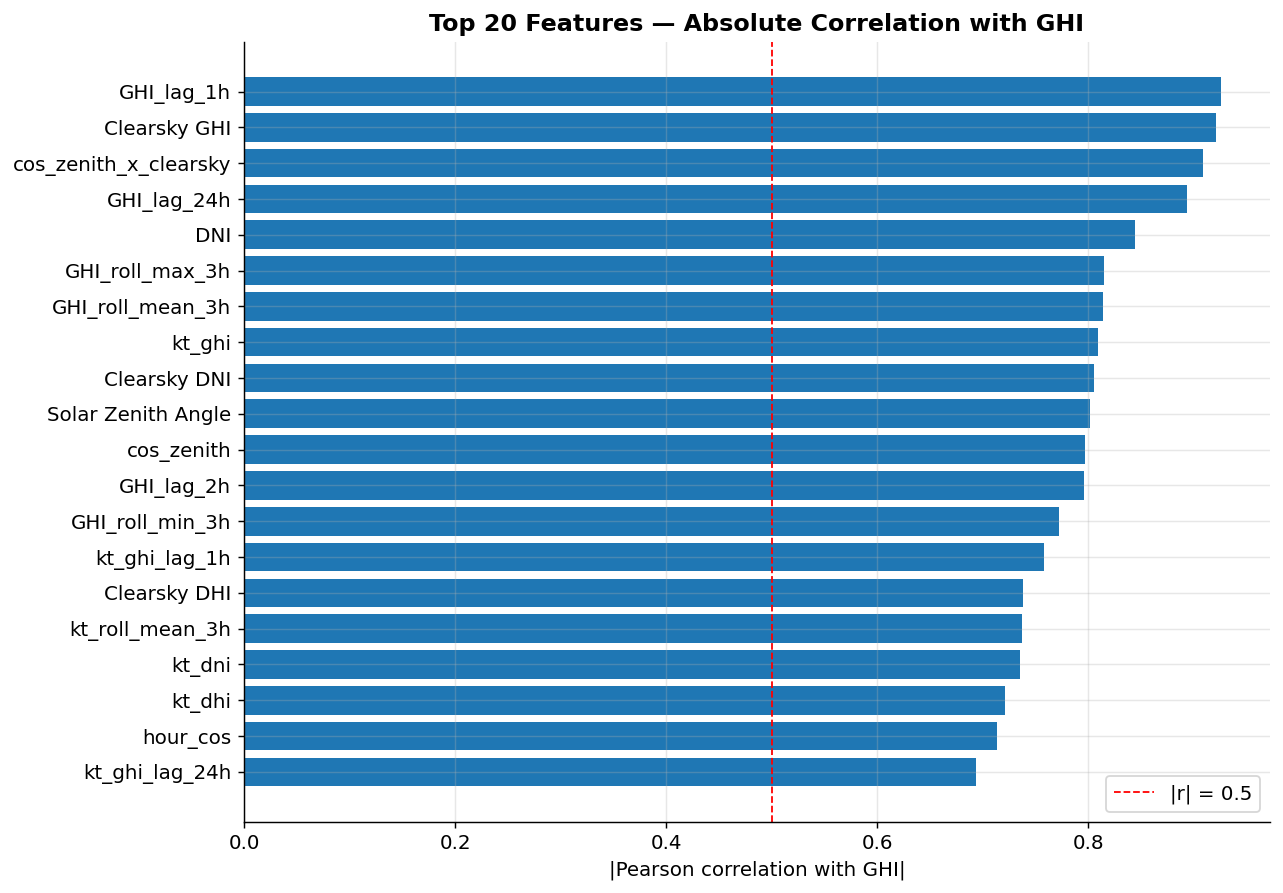

In [47]:
# ── Correlation bar chart ─────────────────────────────────────────────────────
top20 = corr_with_ghi.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1f77b4' if v > 0.5 else '#aec7e8' for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('|Pearson correlation with GHI|')
ax.set_title('Top 20 Features — Absolute Correlation with GHI', fontweight='bold')
ax.axvline(0.5, color='red', linestyle='--', lw=1, label='|r| = 0.5')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/plot_feature_correlation.png', bbox_inches='tight')
plt.show()

Clearsky GHI, cos_zenith, and the clear-sky index Kₜ show the strongest correlation with GHI, confirming that solar geometry and atmospheric clarity are the dominant predictors. Lag features and rolling means also rank highly, validating their inclusion for XGBoost.

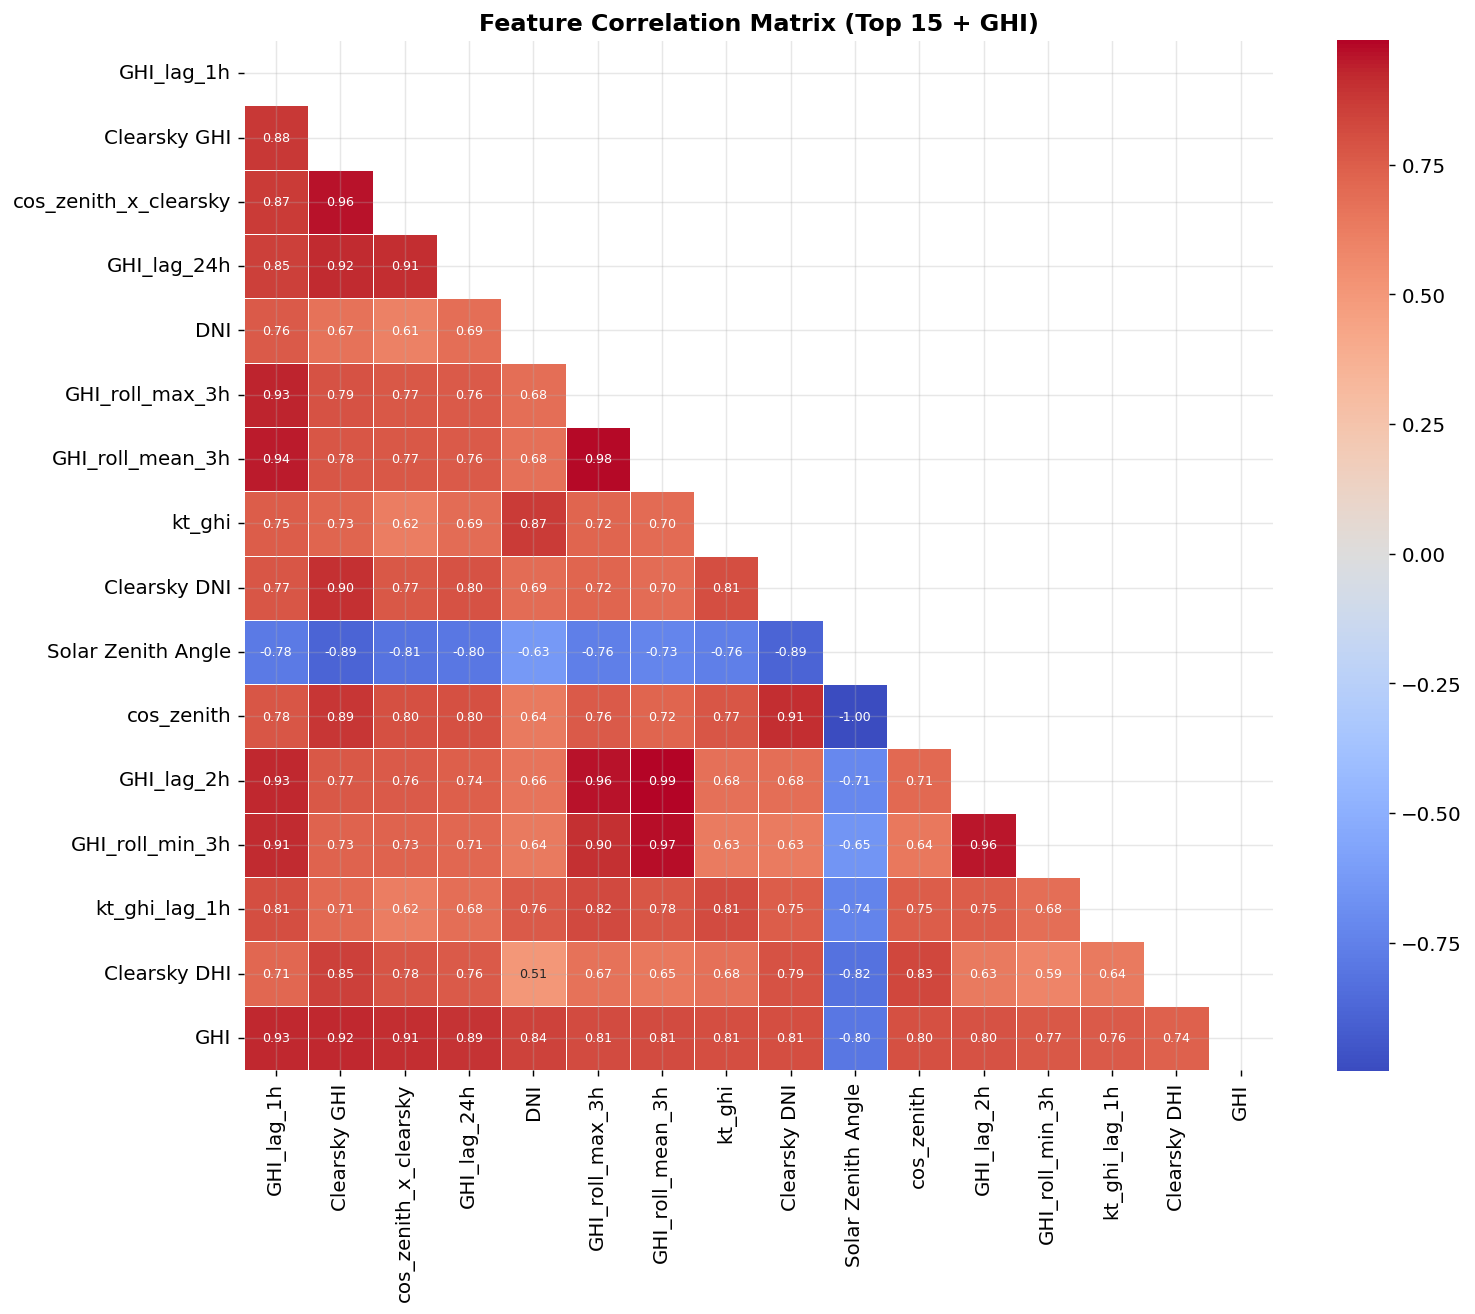

In [48]:
# ── Heatmap of top correlated features (inter-feature multicollinearity) ──────
top_features = corr_with_ghi.head(15).index.tolist() + ['GHI']
corr = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            mask=mask,
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (Top 15 + GHI)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

Several feature pairs show high inter-correlation — notably Clearsky GHI with cos_zenith, and GHI lag features with their rolling means. For SARIMAX, highly collinear exogenous variables will be avoided during model specification to ensure stable parameter estimation.

---
<a id=export></a>
## 10. Export Feature Engineered Data

In [ ]:
df.to_csv('../data/df_engineered.csv')
print(f'Saved df_engineered.csv  →  {df.shape[0]} rows, {df.shape[1]} columns')

---
<a id=feat></a>
## 11. Feature Engineering Summary

In [51]:
feature_groups = {
    'Calendar (raw)'      : ['hour','day_of_week','day_of_year','week_of_year','month','quarter','is_weekend','is_daytime'],
    'Cyclic encoding'     : [c for c in df.columns if '_sin' in c or '_cos' in c],
    'Solar physics'       : ['kt_ghi','kt_dhi','kt_dni','cos_zenith','sin_zenith','diffuse_fraction'],
    'Lag features'        : [c for c in df.columns if 'lag' in c],
    'Rolling statistics'  : [c for c in df.columns if 'roll' in c or 'variability' in c],
    'Interactions/ratios' : ['temp_x_humidity','cloud_clearsky','wind_x_precip_water',
                             'cos_zenith_x_clearsky','GHI_diff_1h','GHI_diff_24h'],
    'Season encoding'     : [c for c in df.columns if 'season' in c],
    'Original predictors' : ['Temperature','Relative Humidity','Wind Speed','Wind Direction',
                             'Cloud Type','Clearsky GHI','Clearsky DHI','Clearsky DNI',
                             'Solar Zenith Angle','Precipitable Water','Surface Albedo'],
}

print('=' * 55)
print(f'  FEATURE ENGINEERING SUMMARY')
print('=' * 55)
total = 0
for group, cols in feature_groups.items():
    present = [c for c in cols if c in df.columns]
    total += len(present)
    print(f'  {group:<22}: {len(present):>3} features')
print('-' * 55)
print(f'  {"Total engineered features":<22}: {total:>3}')
print(f'  {"Original features":<22}:  {15:>2}')
print('=' * 55)

  FEATURE ENGINEERING SUMMARY
  Calendar (raw)        :   8 features
  Cyclic encoding       :  10 features
  Solar physics         :   6 features
  Lag features          :  10 features
  Rolling statistics    :  20 features
  Interactions/ratios   :   6 features
  Season encoding       :   5 features
  Original predictors   :  11 features
-------------------------------------------------------
  Total engineered features:  76
  Original features     :  15


---
## Summary

| Feature group | Count | Used in |
|---|---|---|
| Calendar (raw) | 8 | XGB |
| Cyclic encoding | 10 | SARIMAX, XGB |
| Solar physics (Kt, zenith) | 6 | Both |
| Lag features | 10 | XGB |
| Rolling statistics | 17 | XGB |
| Interactions / ratios | 6 | SARIMAX, XGB |
| Season encoding | 5 | XGB |
| Original predictors | 11 | Both |